In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# Load the dataset
df = pd.read_csv('../data/raw/WA_Fn-UseC HR Attrition - Kaggle Upload-selected-columns.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst look:")
df.head()

Shape: (1470, 10)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber']

First look:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7


In [2]:

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nAttrition breakdown:")
print(df['Attrition'].value_counts())
print("\nAttrition rate:")
print(round(df['Attrition'].value_counts(normalize=True) * 100, 1))

Shape: (1470, 10)

Data types:
Age                 int64
Attrition             str
BusinessTravel        str
DailyRate           int64
Department            str
DistanceFromHome    int64
Education           int64
EducationField        str
EmployeeCount       int64
EmployeeNumber      int64
dtype: object

Missing values:
Age                 0
Attrition           0
BusinessTravel      0
DailyRate           0
Department          0
DistanceFromHome    0
Education           0
EducationField      0
EmployeeCount       0
EmployeeNumber      0
dtype: int64

Attrition breakdown:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate:
Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64


In [3]:
# analytical features
df_clean = df.copy()

# numeric (1 = left, 0 = stayed)
df_clean['Attrition_Flag'] = (df_clean['Attrition'] == 'Yes').astype(int)

# age groups 
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], 
                               bins=[18, 25, 35, 45, 55, 65],
                               labels=['18-25', '26-35', '36-45', '46-55', '56-65'])

# distance category
df_clean['DistanceCategory'] = pd.cut(df_clean['DistanceFromHome'],
                                       bins=[0, 5, 15, 30],
                                       labels=['Near', 'Mid', 'Far'])

print("New columns added:")
print(df_clean[['Age', 'AgeGroup', 'DistanceFromHome', 'DistanceCategory', 'Attrition', 'Attrition_Flag']].head(10))
print("\nAge group distribution:")
print(df_clean['AgeGroup'].value_counts().sort_index())

New columns added:
   Age AgeGroup  DistanceFromHome DistanceCategory Attrition  Attrition_Flag
0   41    36-45                 1             Near       Yes               1
1   49    46-55                 8              Mid        No               0
2   37    36-45                 2             Near       Yes               1
3   33    26-35                 3             Near        No               0
4   27    26-35                 2             Near        No               0
5   32    26-35                 2             Near        No               0
6   59    56-65                 3             Near        No               0
7   30    26-35                24              Far        No               0
8   38    36-45                23              Far        No               0
9   36    36-45                27              Far        No               0

Age group distribution:
AgeGroup
18-25    115
26-35    606
36-45    468
46-55    226
56-65     47
Name: count, dtype: int64


In [4]:
# cleaned data
df_clean.to_csv('../data/processed/hr_clean.csv', index=False)
print("Cleaned CSV saved!")

# Load into SQLite
conn = sqlite3.connect('../data/hr_analytics.db')
df_clean.to_sql('hr_data', conn, if_exists='replace', index=False)


check = pd.read_sql("SELECT COUNT(*) as total FROM hr_data", conn)
print("Rows in database:", check['total'][0])

Cleaned CSV saved!
Rows in database: 1470


In [5]:
# SQL Query 1: Attrition rate by department
q1 = pd.read_sql("""
    SELECT Department,
           COUNT(*) as total_employees,
           SUM(Attrition_Flag) as left_count,
           ROUND(SUM(Attrition_Flag) * 100.0 / COUNT(*), 1) as attrition_rate
    FROM hr_data
    GROUP BY Department
    ORDER BY attrition_rate DESC
""", conn)
print("Attrition by Department:")
print(q1)

# SQL Query 2: Attrition by age group
q2 = pd.read_sql("""
    SELECT AgeGroup,
           COUNT(*) as total,
           SUM(Attrition_Flag) as left_count,
           ROUND(SUM(Attrition_Flag) * 100.0 / COUNT(*), 1) as attrition_rate
    FROM hr_data
    GROUP BY AgeGroup
    ORDER BY AgeGroup
""", conn)
print("\nAttrition by Age Group:")
print(q2)

# SQL Query 3: Attrition by business travel
q3 = pd.read_sql("""
    SELECT BusinessTravel,
           COUNT(*) as total,
           ROUND(SUM(Attrition_Flag) * 100.0 / COUNT(*), 1) as attrition_rate
    FROM hr_data
    GROUP BY BusinessTravel
    ORDER BY attrition_rate DESC
""", conn)
print("\nAttrition by Travel Frequency:")
print(q3)

# SQL Query 4: Attrition by distance from home
q4 = pd.read_sql("""
    SELECT DistanceCategory,
           COUNT(*) as total,
           ROUND(SUM(Attrition_Flag) * 100.0 / COUNT(*), 1) as attrition_rate
    FROM hr_data
    GROUP BY DistanceCategory
    ORDER BY attrition_rate DESC
""", conn)
print("\nAttrition by Distance from Home:")
print(q4)

# SQL Query 5: Daily rate comparison — leavers vs stayers
q5 = pd.read_sql("""
    SELECT Attrition,
           ROUND(AVG(DailyRate), 0) as avg_daily_rate,
           ROUND(AVG(Age), 1) as avg_age,
           COUNT(*) as count
    FROM hr_data
    GROUP BY Attrition
""", conn)
print("\nLeavers vs Stayers — Rate & Age:")
print(q5)

Attrition by Department:
               Department  total_employees  left_count  attrition_rate
0                   Sales              446          92            20.6
1         Human Resources               63          12            19.0
2  Research & Development              961         133            13.8

Attrition by Age Group:
  AgeGroup  total  left_count  attrition_rate
0      NaN      8           4            50.0
1    18-25    115          40            34.8
2    26-35    606         116            19.1
3    36-45    468          43             9.2
4    46-55    226          26            11.5
5    56-65     47           8            17.0

Attrition by Travel Frequency:
      BusinessTravel  total  attrition_rate
0  Travel_Frequently    277            24.9
1      Travel_Rarely   1043            15.0
2         Non-Travel    150             8.0

Attrition by Distance from Home:
  DistanceCategory  total  attrition_rate
0              Far    329            20.7
1              Mid

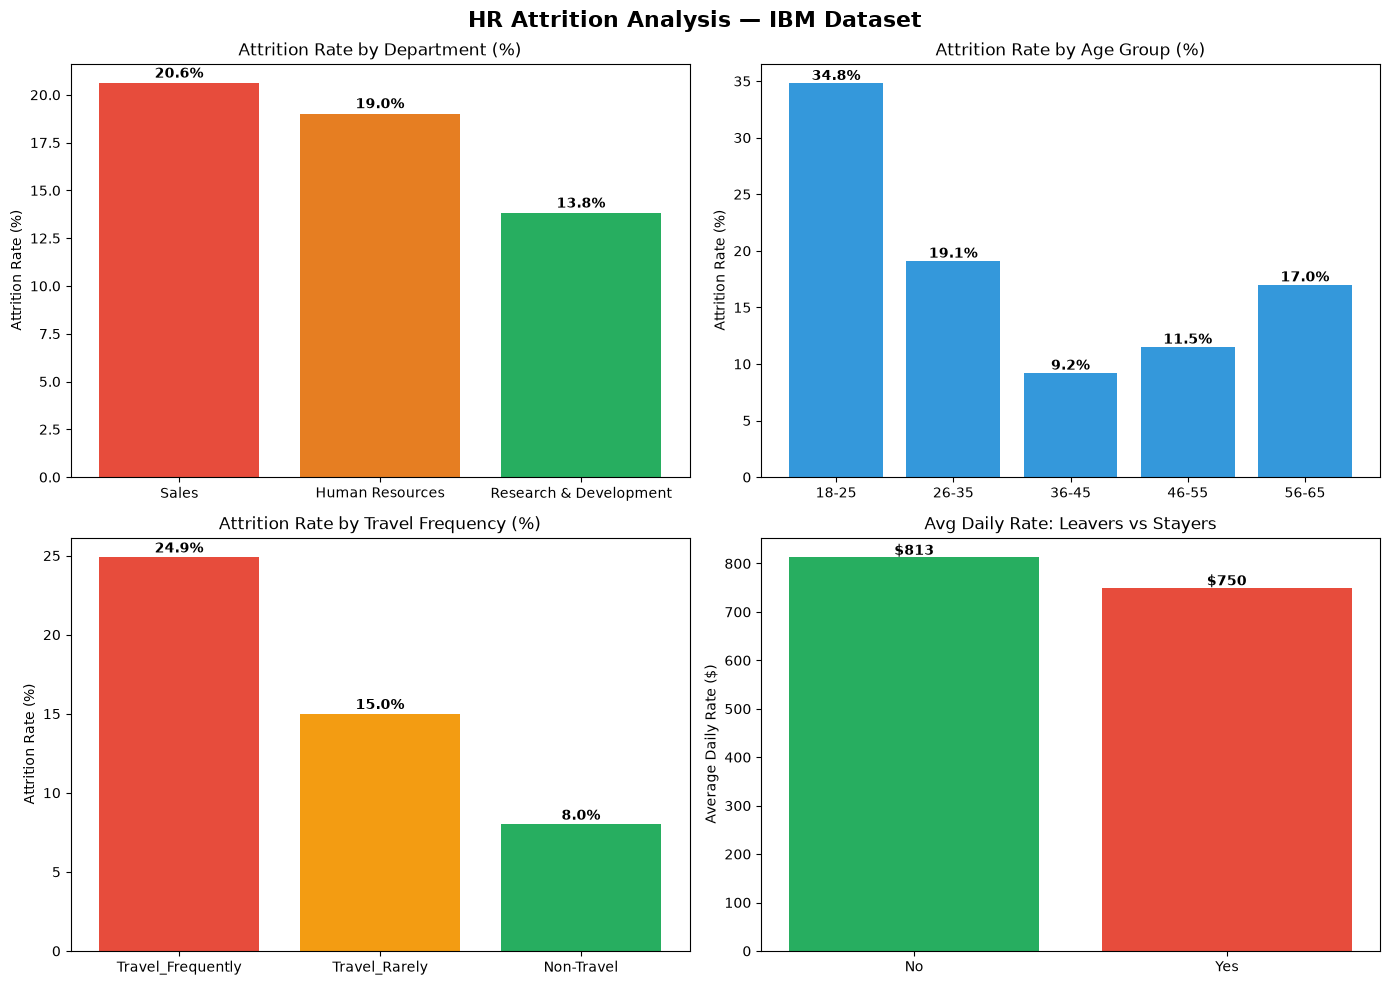

Chart saved!


In [6]:
# Chart 1: Attrition rate by department
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HR Attrition Analysis — IBM Dataset', fontsize=16, fontweight='bold')

# Plot 1: Department attrition
axes[0,0].bar(q1['Department'], q1['attrition_rate'], 
              color=['#e74c3c', '#e67e22', '#27ae60'])
axes[0,0].set_title('Attrition Rate by Department (%)')
axes[0,0].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(q1['attrition_rate']):
    axes[0,0].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

# Plot 2: Attrition by age group
q2_clean = q2.dropna(subset=['AgeGroup'])
axes[0,1].bar(q2_clean['AgeGroup'], q2_clean['attrition_rate'], color='#3498db')
axes[0,1].set_title('Attrition Rate by Age Group (%)')
axes[0,1].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(q2_clean['attrition_rate']):
    axes[0,1].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

# Plot 3: Attrition by travel
axes[1,0].bar(q3['BusinessTravel'], q3['attrition_rate'],
              color=['#e74c3c', '#f39c12', '#27ae60'])
axes[1,0].set_title('Attrition Rate by Travel Frequency (%)')
axes[1,0].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(q3['attrition_rate']):
    axes[1,0].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold')

# Plot 4: Leavers vs Stayers daily rate
axes[1,1].bar(q5['Attrition'], q5['avg_daily_rate'],
              color=['#27ae60', '#e74c3c'])
axes[1,1].set_title('Avg Daily Rate: Leavers vs Stayers')
axes[1,1].set_ylabel('Average Daily Rate ($)')
for i, v in enumerate(q5['avg_daily_rate']):
    axes[1,1].text(i, v + 5, f'${v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../dashboard/hr_attrition_analysis.png', dpi=150)
plt.show()
print("Chart saved!")

In [7]:
# Save SQL queries to file
sql_content = """-- ============================================
-- HR Attrition Analysis SQL Queries
-- Dataset: IBM HR Analytics (Kaggle)
-- ============================================

-- Query 1: Attrition rate by department
SELECT Department,
       COUNT(*) as total_employees,
       SUM(Attrition_Flag) as left_count,
       ROUND(SUM(Attrition_Flag) * 100.0 / COUNT(*), 1) as attrition_rate
FROM hr_data
GROUP BY Department
ORDER BY attrition_rate DESC;

-- Query 2: Attrition by age group
SELECT AgeGroup,
       COUNT(*) as total,
       SUM(Attrition_Flag) as left_count,
       ROUND(SUM(Attrition_Flag) * 100.0 / COUNT(*), 1) as attrition_rate
FROM hr_data
GROUP BY AgeGroup
ORDER BY AgeGroup;

-- Query 3: Attrition by business travel frequency
SELECT BusinessTravel,
       COUNT(*) as total,
       ROUND(SUM(Attrition_Flag) * 100.0 / COUNT(*), 1) as attrition_rate
FROM hr_data
GROUP BY BusinessTravel
ORDER BY attrition_rate DESC;

-- Query 4: Attrition by distance from home
SELECT DistanceCategory,
       COUNT(*) as total,
       ROUND(SUM(Attrition_Flag) * 100.0 / COUNT(*), 1) as attrition_rate
FROM hr_data
GROUP BY DistanceCategory
ORDER BY attrition_rate DESC;

-- Query 5: Daily rate and age comparison — leavers vs stayers
SELECT Attrition,
       ROUND(AVG(DailyRate), 0) as avg_daily_rate,
       ROUND(AVG(Age), 1) as avg_age,
       COUNT(*) as count
FROM hr_data
GROUP BY Attrition;
"""

with open('../sql/hr_analysis_queries.sql', 'w') as f:
    f.write(sql_content)
print("SQL file saved!")

# Save cleaned CSV
df_clean.to_csv('../data/processed/hr_clean.csv', index=False)
print("Cleaned CSV saved!")

SQL file saved!
Cleaned CSV saved!
